In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
data = pd.read_csv('Housing.csv')

In [33]:
data.shape

(545, 13)

In [34]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [36]:
data.isnull().sum().sum()

np.int64(0)

In [37]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]
print(f"Number of outliers in price: {len(outliers)}")

Number of outliers in price: 15


Text(0.5, 1.0, 'Price Boxplot (Before Outlier Removal)')

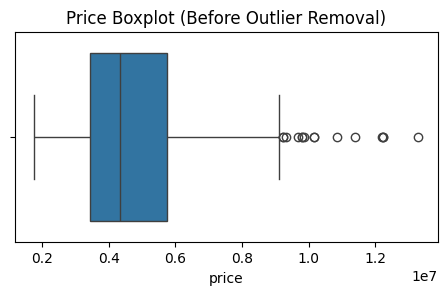

In [40]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Price Boxplot (Before Outlier Removal)')

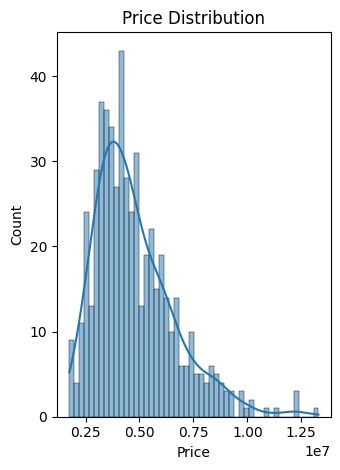

In [39]:
plt.subplot(1, 2, 2)
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

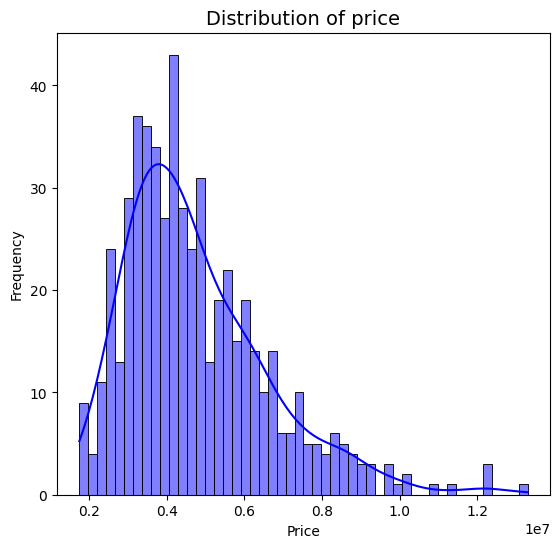

In [41]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(data['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of price', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')

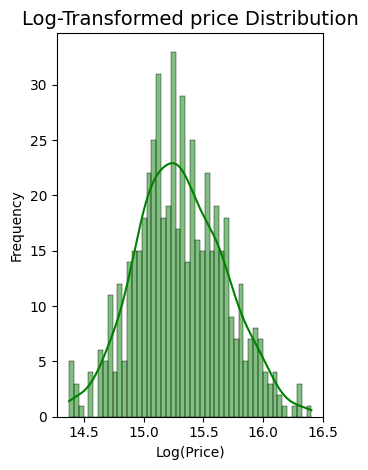

In [44]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(data['price']), bins=50, kde=True, color='green')
plt.title('Log-Transformed price Distribution', fontsize=14)
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [45]:
data['price'].describe()

,price
count,5.450000e+02
mean,4.766729e+06
std,1.870440e+06
min,1.750000e+06
25%,3.430000e+06
50%,4.340000e+06
75%,5.740000e+06
max,1.330000e+07


In [47]:
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

In [51]:
top_corr = correlation_matrix['price'].sort_values(ascending=False).head(11)
top_corr

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


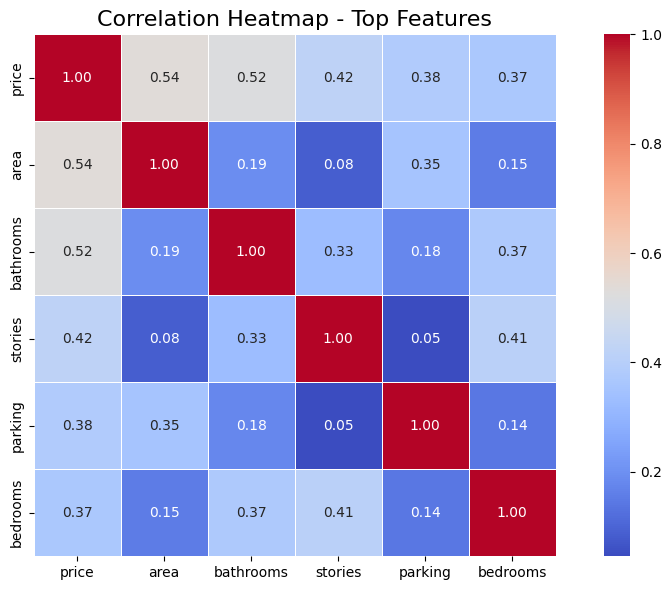

In [56]:
plt.figure(figsize=(10, 6))
top_features = top_corr.index.tolist()
sns.heatmap(numeric_data[top_features].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Top Features', fontsize=16)
plt.tight_layout()
plt.show()

In [59]:
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

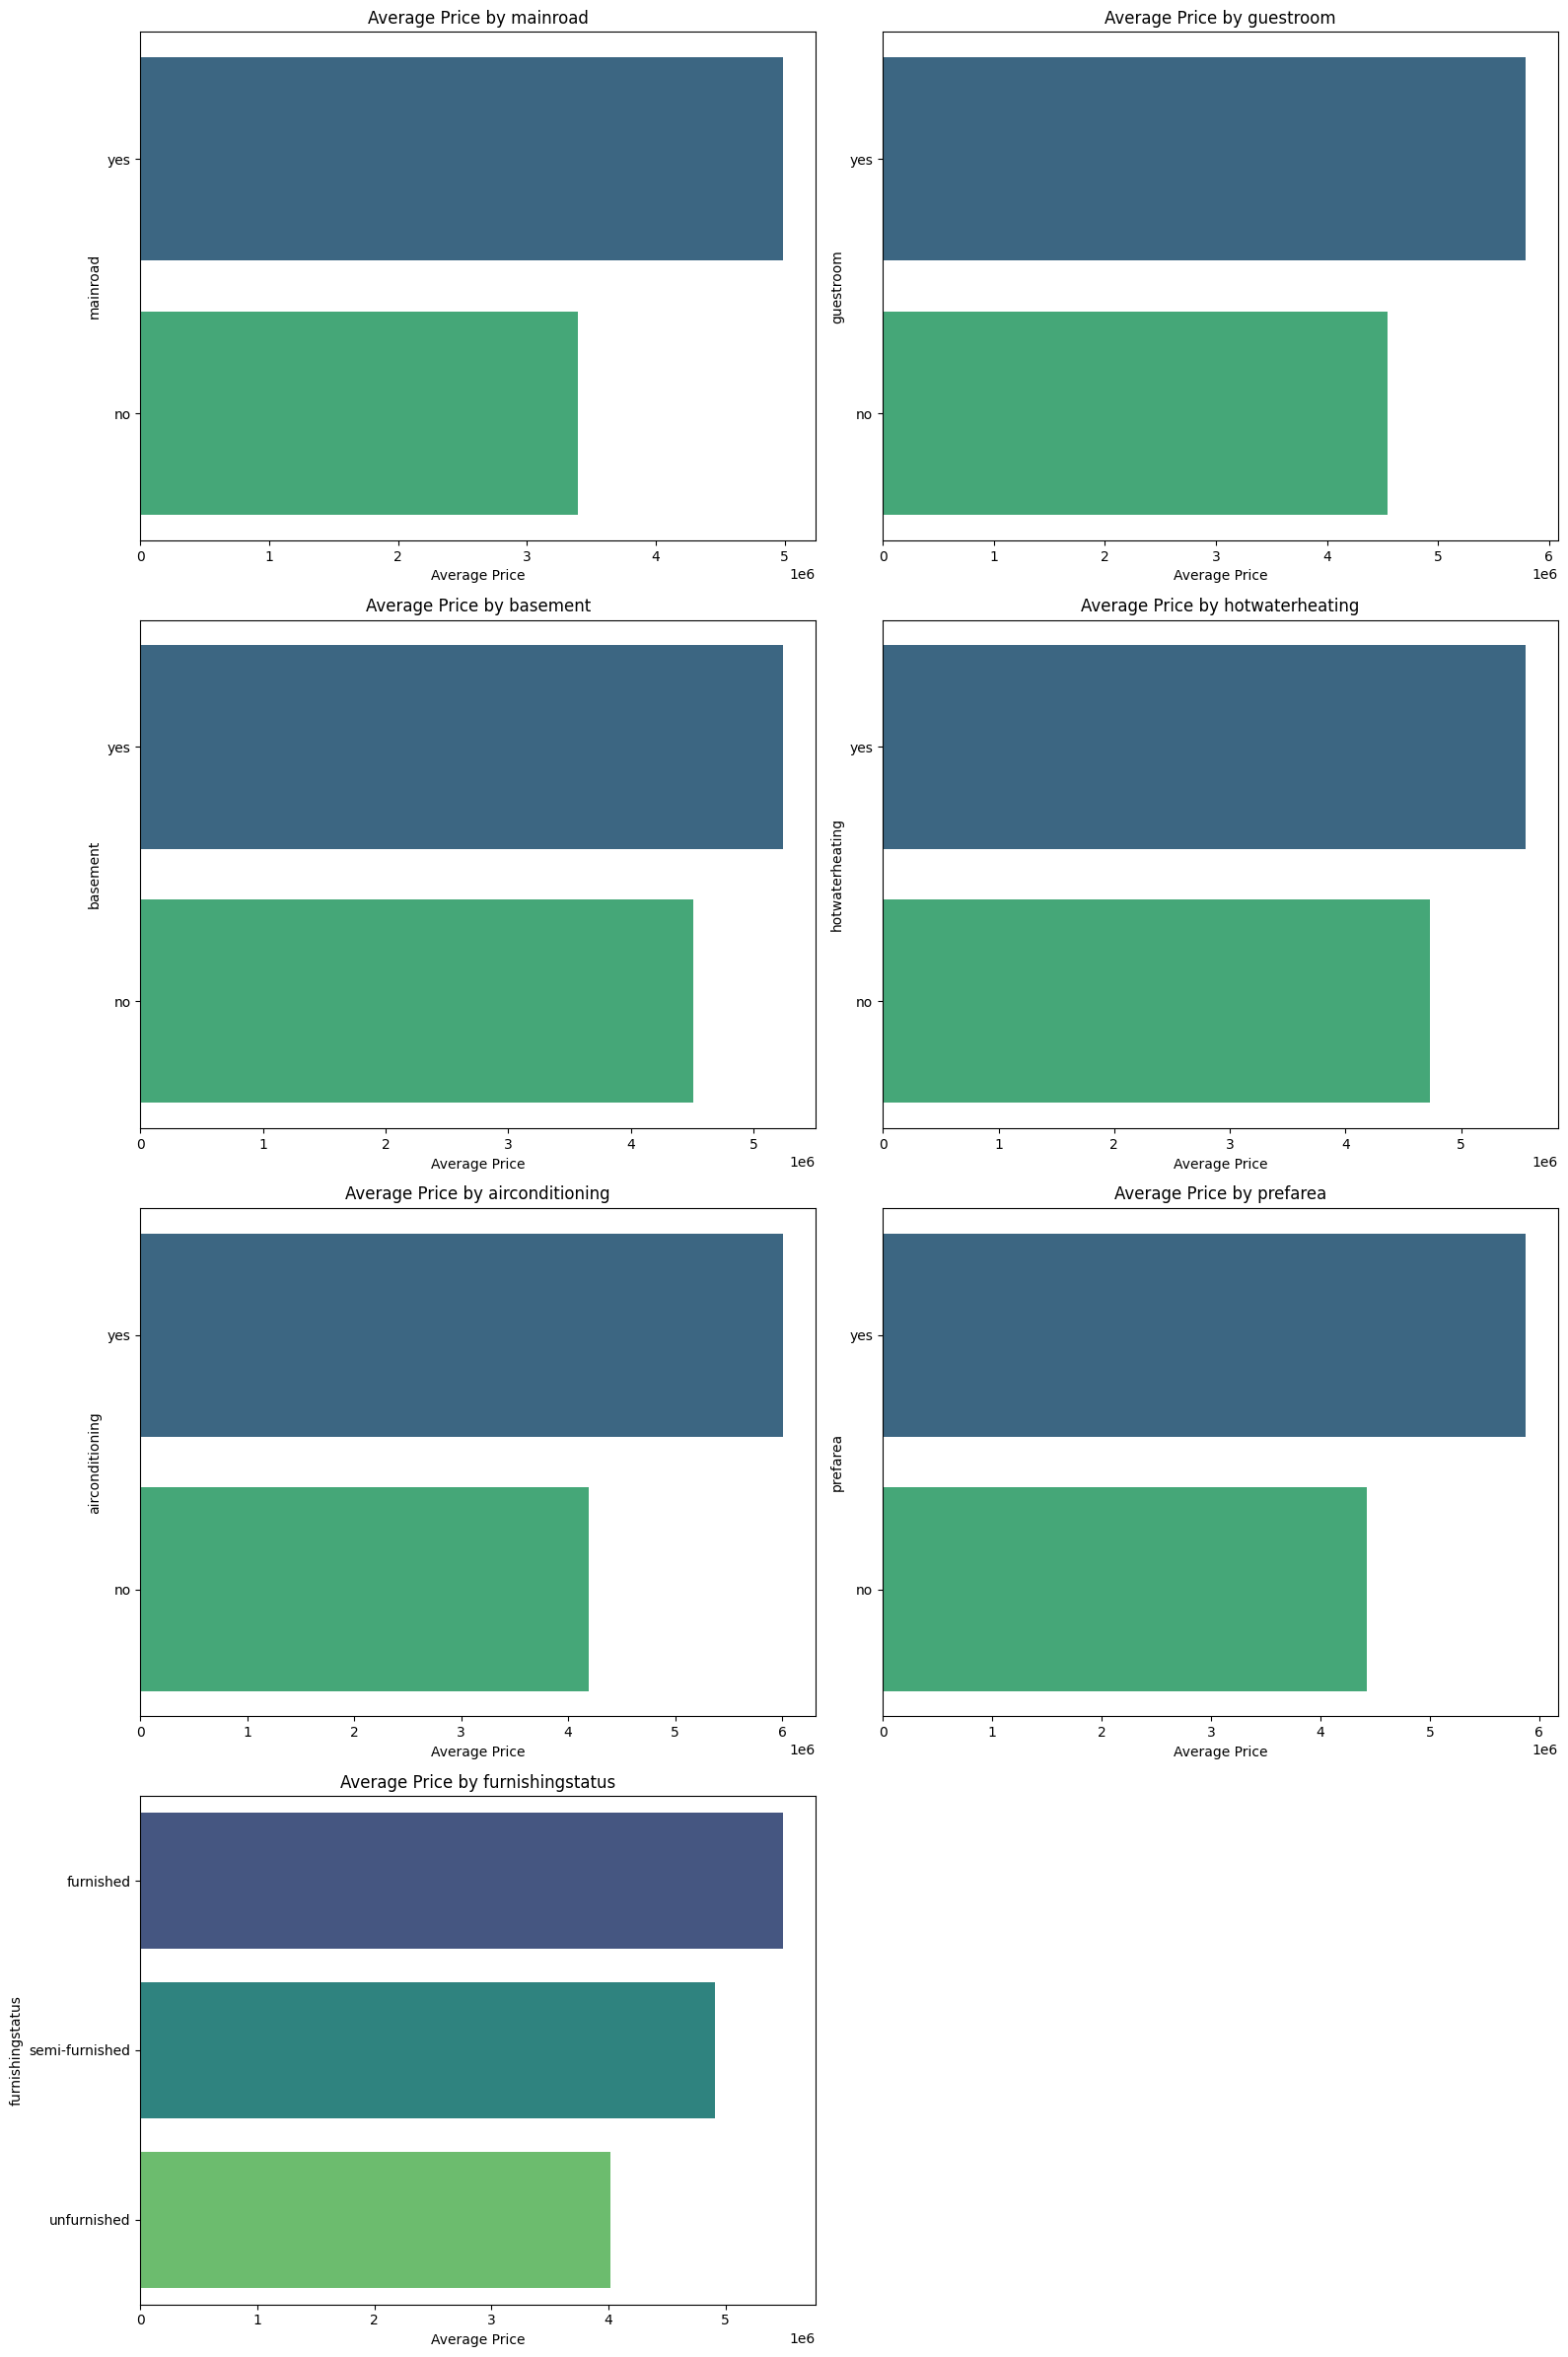

In [63]:
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus']


fig, axes = plt.subplots(4, 2, figsize=(16, 24))

for i, feature in enumerate(categorical_features):
    row, col = i // 2, i % 2
    avg_price = data.groupby(feature)['price'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=avg_price.values, y=avg_price.index, ax=axes[row, col], palette='viridis')
    axes[row, col].set_title(f'Average Price by {feature}', fontsize=12)
    axes[row, col].set_xlabel('Average Price')
    axes[row, col].set_ylabel(feature)

for i in range(len(categorical_features), 4 * 2):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

In [64]:
y = data['price']


In [65]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [67]:
feature_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']

X = data[feature_cols]


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape[0]

436

In [73]:
X_test.shape[0]

109

In [76]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


categorical_cols = X_train.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

In [78]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [79]:
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

In [80]:
r2_score(y_train, y_train_pred_lr)

0.6854429472843789

In [90]:
f'{np.sqrt(mean_squared_error(y_train, y_train_pred_lr)):.2f}'

'984836.44'

In [91]:
f'{mean_absolute_error(y_train, y_train_pred_lr):.2f}'

'718146.60'

In [118]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)

In [119]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

In [120]:
f'{r2_score(y_train, y_train_pred_dt):.4f}'

'0.8443'

In [121]:
f'{np.sqrt(mean_squared_error(y_train, y_train_pred_dt)):.2f}'

'692934.77'

In [122]:
f'{mean_absolute_error(y_train, y_train_pred_dt):.2f}'

'481482.84'

In [123]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15,
                                  min_samples_split=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_split=10, n_jobs=-1,
                      random_state=42)

In [124]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [125]:
f'{r2_score(y_train, y_train_pred_rf):.4f}'

'0.8453'

In [126]:
f'{np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.2f}'

'690655.78'

In [127]:
f' {mean_absolute_error(y_train, y_train_pred_rf):.2f}'

' 487758.81'

In [131]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train R²': [r2_score(y_train, y_train_pred_lr),
                 r2_score(y_train, y_train_pred_dt),
                 r2_score(y_train, y_train_pred_rf)],
    'Test R²': [r2_score(y_test, y_test_pred_lr),
                r2_score(y_test, y_test_pred_dt),
                r2_score(y_test, y_test_pred_rf)],
    'Train RMSE': [np.sqrt(mean_squared_error(y_train, y_train_pred_lr)),
                   np.sqrt(mean_squared_error(y_train, y_train_pred_dt)),
                   np.sqrt(mean_squared_error(y_train, y_train_pred_rf))],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
                  np.sqrt(mean_squared_error(y_test, y_test_pred_dt)),
                  np.sqrt(mean_squared_error(y_test, y_test_pred_rf))],
    'Test MAE': [mean_absolute_error(y_test, y_test_pred_lr),
                 mean_absolute_error(y_test, y_test_pred_dt),
                 mean_absolute_error(y_test, y_test_pred_rf)]
})


print(results.to_string(index=False))

            Model  Train R²  Test R²    Train RMSE    Test RMSE     Test MAE
Linear Regression  0.685443 0.649475 984836.442613 1.331071e+06 9.796797e+05
    Decision Tree  0.844276 0.436604 692934.773240 1.687520e+06 1.266332e+06
    Random Forest  0.845299 0.588489 690655.782688 1.442224e+06 1.047274e+06


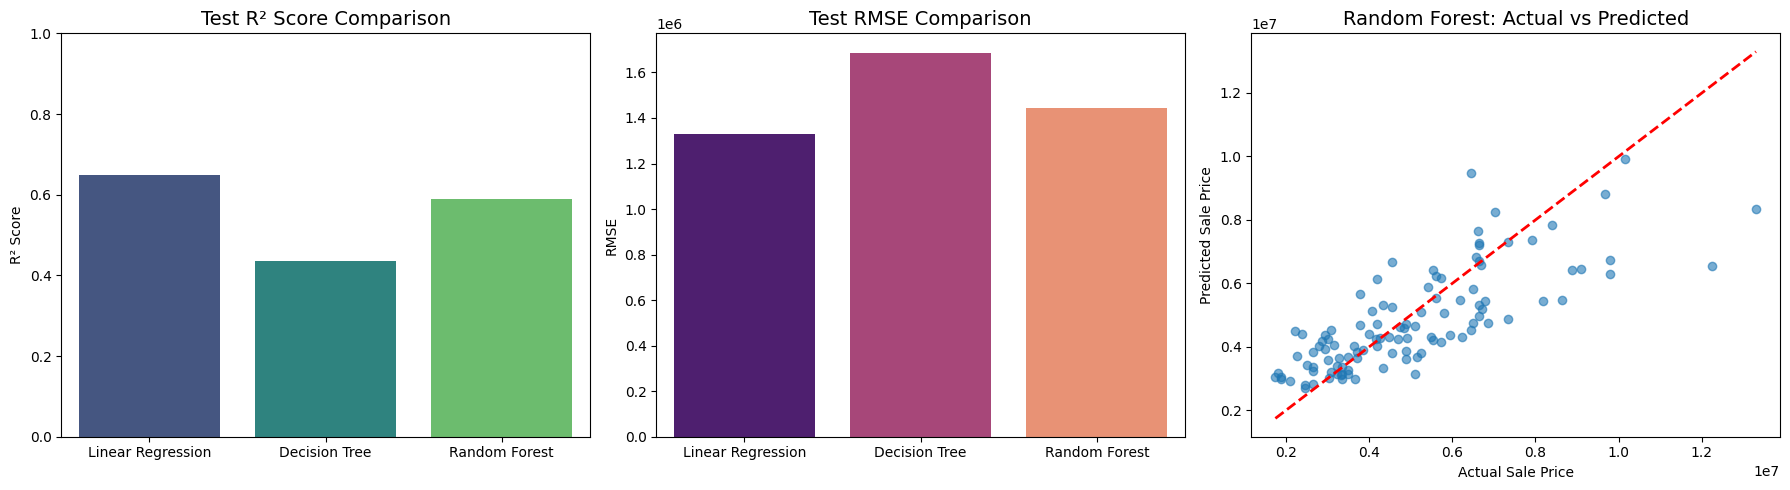

In [132]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
test_r2 = [r2_score(y_test, y_test_pred_lr), r2_score(y_test, y_test_pred_dt), r2_score(y_test, y_test_pred_rf)]
test_rmse = [np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_test_pred_dt)),
             np.sqrt(mean_squared_error(y_test, y_test_pred_rf))]

# R² Score comparison
sns.barplot(x=models, y=test_r2, ax=axes[0], palette='viridis')
axes[0].set_title('Test R² Score Comparison', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)

# RMSE comparison
sns.barplot(x=models, y=test_rmse, ax=axes[1], palette='magma')
axes[1].set_title('Test RMSE Comparison', fontsize=14)
axes[1].set_ylabel('RMSE')

# Actual vs Predicted - Best Model (Random Forest)
axes[2].scatter(y_test, y_test_pred_rf, alpha=0.6)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title('Random Forest: Actual vs Predicted', fontsize=14)
axes[2].set_xlabel('Actual Sale Price')
axes[2].set_ylabel('Predicted Sale Price')

plt.tight_layout()
plt.show()